# **Diplomado IA: Inteligencia Artificial II - Parte 2**. <br> Práctico 32: Aprendizaje Incremental y  Olvido Catastrófico
---
---

## **Profesores:**
- Alain Raymond

### **Ayudante**:

---

El siguiente práctico se debe realizar de forma individual. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita, deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código como respuesta.

**Nombre alumno:**

El siguiente práctico contendrá 1 o más actividades a realizar. Algunas actividades corresponderán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.


---
**IMPORTANTE:** habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0

# Introducción

Este laboratorio se basó en una serie de Notebooks del grupo [Continual AI](https://www.continualai.org/), la cual es una comunidad abierta que busca desarrollar investigación y divulgación sobre Aprendizaje Continuo.

Tal como vimos en clases, el aprendizaje incremental estudia modelos y métodos que permitan un proceso de aprendizaje continuo de varias tareas diferentes.

En este laboratorio vamos a ver cómo se comportan diferentes métodos simples en una secuencia de tareas muy utilizadas para comparación entre métodos.


Lo primero que tenemos que hacer es verificar cómo están los niveles de memoria y disco. Luego verificamos si tenemos acceso a GPU.

In [1]:
!free -m
!df -h
!nvidia-smi

               total        used        free      shared  buff/cache   available
Mem:           12975         687        8555           2        3732       11968
Swap:              0           0           0
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   44G   70G  39% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.2G  748M  63% /usr/sbin/docker-init
/dev/sda1       119G   48G   71G  41% /opt/bin/.nvidia
tmpfs           6.4G   32K  6.4G   1% /var/colab
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
Mon Apr 13 03:33:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------

In [2]:
import torch
torch.cuda.is_available()

True

Cargamos todas las librerias que vamos a utilizar durante este laboratorio:

In [3]:
import random
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Modelo

In [4]:
# switch to False to use CPU
use_cuda = True

use_cuda = use_cuda and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
torch.manual_seed(1);

El modelo consiste en 2 capas convolucionales más dos capas lineales, se agregan capas de max pooling y funciones de activación.

El modelo utilizado es simple ya que la motivación no es lograr los mejores resultados en cada tarea, sino que nos permite reflejar lo que ocurre cuando no tenemos precauciones al entrenar una nueva tarea.


In [5]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return x

# Dataset

En este laboratorio vamos a utilizar el dataset *MNIST* (LeCun, Yann, et al. "Gradient-based learning applied to document recognition." Proceedings of the IEEE 86.11 (1998): 2278-2324.). Este dataset consiste en 60.000 imágenes de 28x28 pixeles, y cada una es una imagen de un dígito del 0 al 9 escrita a mano. Es decir, tiene 10 clases diferentes (una por dígito).

Por simplicidad vamos a utilizar las funciones de descarga de Continual AI, ya que nos va a facilitar la creación de nuevas tareas.


In [6]:
!git clone https://github.com/ContinualAI/colab.git continualai/colab

Cloning into 'continualai/colab'...
remote: Enumerating objects: 402, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 402 (delta 88), reused 81 (delta 66), pack-reused 258 (from 1)
Receiving objects: 100% (402/402), 31.20 MiB | 5.55 MiB/s, done.
Resolving deltas: 100% (208/208), done.


Descargamos el dataset en nuestro entorno de colab

In [7]:
from os import path
import gzip
import pickle
import numpy as np

filename = [
    ["training_images", "train-images-idx3-ubyte.gz"],
    ["test_images", "t10k-images-idx3-ubyte.gz"],
    ["training_labels", "train-labels-idx1-ubyte.gz"],
    ["test_labels", "t10k-labels-idx1-ubyte.gz"]
]

!wget https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz -q --show-progress
!wget https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz -q --show-progress

!wget https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz -q --show-progress
!wget https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz -q --show-progress

def save_mnist():
    mnist = {}
    for name in filename[:2]:
        with gzip.open(name[1], 'rb') as f:
            tmp = np.frombuffer(f.read(), np.uint8, offset=16)
            mnist[name[0]] = tmp.reshape(-1, 1, 28, 28).astype(np.float32) / 255
    for name in filename[-2:]:
        with gzip.open(name[1], 'rb') as f:
            mnist[name[0]] = np.frombuffer(f.read(), np.uint8, offset=8)
    with open("mnist.pkl", 'wb') as f:
        pickle.dump(mnist, f)
    print("Save complete.")

save_mnist()

train-images-idx3-u 100%[===================>]   9.45M  12.1MB/s    in 0.8s    
train-labels-idx1-u 100%[===================>]  28.20K  --.-KB/s    in 0.09s   
t10k-images-idx3-ub 100%[===================>]   1.57M  3.05MB/s    in 0.5s    
t10k-labels-idx1-ub 100%[===================>]   4.44K  --.-KB/s    in 0s      
Save complete.


In [8]:
from continualai.colab.scripts import mnist
mnist.init()

Files already downloaded!


100%|██████████| 9.91M/9.91M [00:00<00:00, 11.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.21MB/s]


Luego lo cargamos a memoria.

El dataset que estamos utilizando es muy simple, ideal para hacer pruebas de concepto, ya que tiene varias imagenes pequeñas. Al ser pequeñas, estas se pueden cargar en memoria completamente, lo que acelera bastante el proceso de entrenamiento.

Lo bueno de probar estos métodos en pequeños dataset es que nos permite validar nuestra propuesta antes de consumir horas o días de computo probando en otra secuencia de tareas. Pero una vez que validamos las ideas, podemos probar los mismos métodos en otras tareas.

In [9]:
x_train, y_train, x_test, y_test = mnist.load()

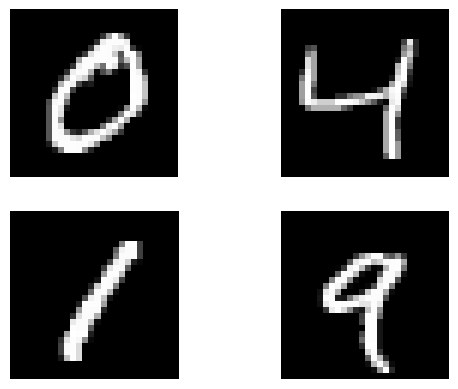

In [10]:
f, axarr = plt.subplots(2,2)
axarr[0,0].imshow(x_train[1, 0], cmap="gray")
axarr[0,1].imshow(x_train[2, 0], cmap="gray")
axarr[1,0].imshow(x_train[3, 0], cmap="gray")
axarr[1,1].imshow(x_train[4, 0], cmap="gray")
np.vectorize(lambda ax:ax.axis('off'))(axarr);

## Permuted MNIST

Esta secuencia de tareas consiste en tomar cada imagen del set original del dataset MNIST, y realizar una permutación de los pixeles para que refleje otros patrones en la imagen.

Cada tarea que queremos agregar es una nueva permutación que se hace a cada una de las imágenes. Por ejemplo, una nueva tarea puede ser mover todos los píxeles uno a la derecha. Pero lo que se hace normalmente es que cada tarea es una permutación aleatoria de todos los píxeles, buscando generar patrones únicos en cada tarea.

In [11]:
def permute_mnist(mnist, seed):
    """ Given the training set, permute pixels of each img the same way. """

    np.random.seed(seed)
    print("starting permutation...")
    h = w = 28
    perm_inds = list(range(h*w))
    np.random.shuffle(perm_inds)
    # print(perm_inds)
    perm_mnist = []
    for set in mnist:
        num_img = set.shape[0]
        flat_set = set.reshape(num_img, w * h)
        perm_mnist.append(flat_set[:, perm_inds].reshape(num_img, 1, w, h))
    print("done.")
    return perm_mnist

starting permutation...
done.


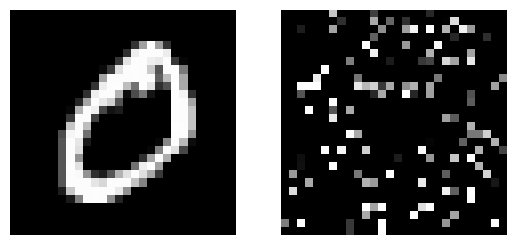

In [12]:
x_train2, x_test2 = permute_mnist([x_train, x_test], 0)
f, axarr = plt.subplots(1,2)
axarr[0].imshow(x_train[1, 0], cmap="gray")
axarr[1].imshow(x_train2[2, 0], cmap="gray")
np.vectorize(lambda ax:ax.axis('off'))(axarr);

starting permutation...
done.


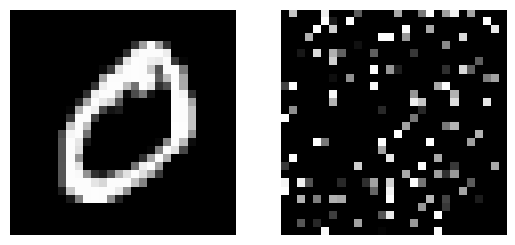

In [13]:
x_train2, x_test2 = permute_mnist([x_train, x_test], 5)
f, axarr = plt.subplots(1,2)
axarr[0].imshow(x_train[1, 0], cmap="gray")
axarr[1].imshow(x_train2[2, 0], cmap="gray")
np.vectorize(lambda ax:ax.axis('off'))(axarr);

# Entrenamiento

Tal como en laboratorios anteriores, tenemos dos funciones que nos ayudan a entrenar e ir verificando cómo van los entrenamientos de nuestro modelo.

**train**: Es la encargada de entrenar el modelo con los datos que le entregamos. Estos deben ser de la tarea actual.

**test**: Nos devuelve el accuracy logrado por el modelo con los datos que le entregamos.

In [14]:
def train(model, device, x_train, y_train, optimizer, epoch):
    model.train()

    for start in range(0, len(y_train)-1, 256):
        end = start + 256
        x, y = torch.from_numpy(x_train[start:end]), torch.from_numpy(y_train[start:end]).long()
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)
        loss = F.cross_entropy(output, y)
        loss.backward()
        optimizer.step()
        #print(loss.item())
    print('Train Epoch: {} \tLoss: {:.6f}'.format(epoch, loss.item()))

def test(model, device, x_test, y_test):
    model.eval()
    test_loss = 0
    correct = 0
    for start in range(0, len(y_test)-1, 256):
       end = start + 256
       with torch.no_grad():
          x, y = torch.from_numpy(x_test[start:end]), torch.from_numpy(y_test[start:end]).long()
          x, y = x.to(device), y.to(device)
          output = model(x)
          test_loss += F.cross_entropy(output, y).item() # sum up batch loss
          pred = output.max(1, keepdim=True)[1] # get the index of the max logit
          correct += pred.eq(y.view_as(pred)).sum().item()

    test_loss /= len(y_test)
    print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(y_test),
        100. * correct / len(y_test)))
    return 100. * correct / len(y_test)

Es importante inicializar el modelo cada vez que queramos entrenar una nueva secuencia, ya que si no lo hacemos estamos partiendo con un modelo que ya tiene información de alguna tarea en sus pesos.

In [15]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [16]:
for epoch in range(1, 5):
   train(model, device, x_train, y_train, optimizer, epoch)
   test(model, device, x_test, y_test)

Train Epoch: 1 	Loss: 0.762164
Test set: Average loss: 0.0013, Accuracy: 9021/10000 (90%)

Train Epoch: 2 	Loss: 0.497769
Test set: Average loss: 0.0007, Accuracy: 9427/10000 (94%)

Train Epoch: 3 	Loss: 0.481222
Test set: Average loss: 0.0005, Accuracy: 9563/10000 (96%)

Train Epoch: 4 	Loss: 0.464888
Test set: Average loss: 0.0005, Accuracy: 9623/10000 (96%)



Con los resultados anteriores, podemos ver que el modelo logró un muy buen rendimiento en la tarea con los datos original. Lo mejor, es que no necesita una gran cantidad de épocas para alcanzar esos resultados.

## Olvido Catastrófico

El mayor problema que tiene el aprender tareas de manera secuencial es lo que se conoce como Olvido Catastrófico, donde al entrenar una nueva tarea, el rendimiento alcanzado en tareas anteriores se ve fuertemente afectado.

Primero veamos el accuracy que alcanza un modelo en dos tareas, cuando fue entrenado solo en la primera:

In [17]:
print("Testing on the first task:")
test(model, device, x_test, y_test)

print("Testing on the second task:")
test(model, device, x_test2, y_test);

Testing on the first task:
Test set: Average loss: 0.0005, Accuracy: 9623/10000 (96%)

Testing on the second task:
Test set: Average loss: 0.0099, Accuracy: 1040/10000 (10%)



Como era esperado, a nuestro modelo no le va bien en una tarea en la cual no ha sido entrenado. Esto se refleja más todavía cuando las imágenes entre las tareas son bien diferentes.

Debido a lo anterior, es necesario entrenar el modelo en este nuevo dataset para que adquiera los conocimientos necesarios, y se pueda desempeñar de manera correcta en esta nueva tarea.


In [18]:
for epoch in range(1, 3):
  train(model, device, x_train2, y_train, optimizer, epoch)
  test(model, device, x_test2, y_test)

Train Epoch: 1 	Loss: 1.235989
Test set: Average loss: 0.0031, Accuracy: 7565/10000 (76%)

Train Epoch: 2 	Loss: 0.970796
Test set: Average loss: 0.0021, Accuracy: 8300/10000 (83%)



In [19]:
print("Testing on the first task:")
test(model, device, x_test, y_test)

print("Testing on the second task:")
test(model, device, x_test2, y_test);

Testing on the first task:
Test set: Average loss: 0.0160, Accuracy: 3271/10000 (33%)

Testing on the second task:
Test set: Average loss: 0.0021, Accuracy: 8300/10000 (83%)



Pero tal como vimos en clases, se produce el problema de olvido catastrófico, donde obtenemos un buen rendimiento en la segunda tarea pero en la primera tarea olvidamos casi todo lo aprendido.

# Estrategias de Aprendizaje Continuo

En este laboratorio vamos a comprobar el rendimiento de 3 metodos diferentes:

1.   Naive: Entrenamiento sin ningun tipo de metodo preocupado de alivianar el problema del olvido
2.   Rehearsal: Tener una memoria con datos de tareas pasadas
3.   Elastic Weight Consolidation (EWC): Uno de los metodo que vimos en clases

Primero vamos a crear las diferentes tareas que vamos a utilizar. La variable *num_tasks* es la encargada de determinar la cantidad de tareas que vamos a probar, y *num_epoch* por cuantas iteraciones vamos a entrenar cada tarea.

In [20]:
num_tasks = 3
num_epoch = 3
tasks = []
for i in range(num_tasks):
    if i > 0:
        train_x, test_x = permute_mnist([x_train, x_test], i)
        task = [(train_x, y_train), (test_x, y_test)]
    else:
        task = [(x_train, y_train), (x_test, y_test)]

    tasks.append(task)

starting permutation...
done.
starting permutation...
done.


## Naive Strategy

A modo de *baseline*, vamos a entrenar el modelo con la estrategia más simple.  Esta consiste en entrenar de manera secuencial todas las tareas sin ningún tipo de estrategia contra el olvido.

In [21]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [22]:
naive_accs = []

for id, task in enumerate(tasks):
    avg_acc = 0
    print("Training on task: ", id)

    (x_train, y_train), _ = task

    for epoch in range(1, num_epoch):
        train(model, device, x_train, y_train, optimizer, epoch)

    for id_test, task in enumerate(tasks):
        print("Testing on task: ", id_test)
        _, (x_test, y_test) = task
        acc = test(model, device, x_test, y_test)
        avg_acc = avg_acc + acc

    naive_accs.append(avg_acc / len(tasks))
    print("Avg acc: ", avg_acc / len(tasks))


Training on task:  0
Train Epoch: 1 	Loss: 0.797410
Train Epoch: 2 	Loss: 0.528520
Testing on task:  0
Test set: Average loss: 0.0006, Accuracy: 9476/10000 (95%)

Testing on task:  1
Test set: Average loss: 0.0113, Accuracy: 622/10000 (6%)

Testing on task:  2
Test set: Average loss: 0.0098, Accuracy: 1297/10000 (13%)

Avg acc:  37.983333333333334
Training on task:  1
Train Epoch: 1 	Loss: 1.862655
Train Epoch: 2 	Loss: 1.619446
Testing on task:  0
Test set: Average loss: 0.0210, Accuracy: 2106/10000 (21%)

Testing on task:  1
Test set: Average loss: 0.0035, Accuracy: 7384/10000 (74%)

Testing on task:  2
Test set: Average loss: 0.0127, Accuracy: 1212/10000 (12%)

Avg acc:  35.67333333333334
Training on task:  2
Train Epoch: 1 	Loss: 1.666108
Train Epoch: 2 	Loss: 1.222021
Testing on task:  0
Test set: Average loss: 0.0216, Accuracy: 2463/10000 (25%)

Testing on task:  1
Test set: Average loss: 0.0082, Accuracy: 2935/10000 (29%)

Testing on task:  2
Test set: Average loss: 0.0026, Accu

### Actividad Practica 1

> Interpretación guiada para alumno novato

> 1) ¿Afecta el orden de las tareas?
Sí, en general **sí afecta**. En aprendizaje incremental (sin método anti-olvido), el modelo ajusta sus pesos a la tarea más reciente. Por eso, si cambias el orden, cambias qué tarea queda “más fresca” en los pesos finales.

Puntos clave:
- La última tarea entrenada suele tener mejor desempeño relativo.
- Tareas entrenadas al principio tienden a degradarse más (olvido catastrófico).
- Con orden inverso, la curva puede cambiar y la tarea beneficiada también cambia.

> 2) ¿Qué pasa al agregar más tareas en Naive?
El **accuracy promedio normalmente baja** a medida que aumentan las tareas.

Razón principal:
- El modelo tiene capacidad limitada y, al aprender secuencialmente sin regularización/memoria, sobreescribe información útil para tareas anteriores.

Conclusión de Actividad 1:
- Naive funciona como baseline simple.
- Es sensible al orden y escala peor cuando crece el número de tareas.
- Esto motiva usar estrategias como Rehearsal o EWC.

Train Epoch: 1 	Loss: 0.767091
Train Epoch: 2 	Loss: 0.618562
Test set: Average loss: 0.0007, Accuracy: 9424/10000 (94%)

Test set: Average loss: 0.0112, Accuracy: 524/10000 (5%)

Test set: Average loss: 0.0099, Accuracy: 1203/10000 (12%)

Train Epoch: 1 	Loss: 1.596854
Train Epoch: 2 	Loss: 1.190179
Test set: Average loss: 0.0192, Accuracy: 1410/10000 (14%)

Test set: Average loss: 0.0028, Accuracy: 7884/10000 (79%)

Test set: Average loss: 0.0125, Accuracy: 1265/10000 (13%)

Train Epoch: 1 	Loss: 1.328384
Train Epoch: 2 	Loss: 1.097572
Test set: Average loss: 0.0174, Accuracy: 2678/10000 (27%)

Test set: Average loss: 0.0085, Accuracy: 2849/10000 (28%)

Test set: Average loss: 0.0025, Accuracy: 8152/10000 (82%)

Train Epoch: 1 	Loss: 2.218980
Train Epoch: 2 	Loss: 1.221884
Test set: Average loss: 0.0029, Accuracy: 7865/10000 (79%)

Test set: Average loss: 0.0110, Accuracy: 1427/10000 (14%)

Test set: Average loss: 0.0222, Accuracy: 1815/10000 (18%)

Train Epoch: 1 	Loss: 1.106774
Tra

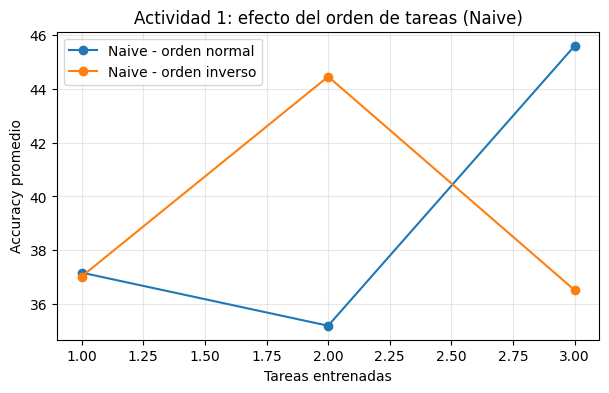

starting permutation...
done.
starting permutation...
done.
Train Epoch: 1 	Loss: 2.052826
Train Epoch: 2 	Loss: 1.109783
Test set: Average loss: 0.0027, Accuracy: 8101/10000 (81%)

Test set: Average loss: 0.0107, Accuracy: 1293/10000 (13%)

Train Epoch: 1 	Loss: 1.358622
Train Epoch: 2 	Loss: 1.026753
Test set: Average loss: 0.0081, Accuracy: 3209/10000 (32%)

Test set: Average loss: 0.0019, Accuracy: 8538/10000 (85%)

num_tasks=2, final_avg_acc=58.7350
starting permutation...
done.
starting permutation...
done.
starting permutation...
done.
Train Epoch: 1 	Loss: 1.893117
Train Epoch: 2 	Loss: 1.259859
Test set: Average loss: 0.0026, Accuracy: 8057/10000 (81%)

Test set: Average loss: 0.0110, Accuracy: 1260/10000 (13%)

Test set: Average loss: 0.0126, Accuracy: 1074/10000 (11%)

Train Epoch: 1 	Loss: 1.316057
Train Epoch: 2 	Loss: 0.982106
Test set: Average loss: 0.0067, Accuracy: 4025/10000 (40%)

Test set: Average loss: 0.0018, Accuracy: 8613/10000 (86%)

Test set: Average loss: 0.0

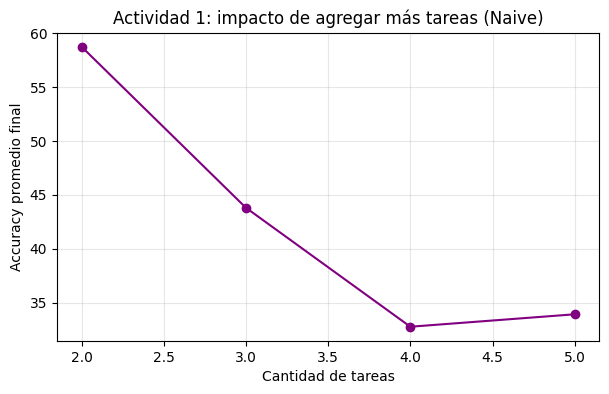

In [26]:
# Actividad Práctica 1 - Experimentos
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim

# ---------------------------------------------------------------------
# Función auxiliar: entrena Naive en un orden dado de tareas
# y devuelve el accuracy promedio después de cada tarea.
# ---------------------------------------------------------------------
def run_naive_sequence(tasks_sequence, num_epoch_local=3):
    model_local = Net().to(device)
    optimizer_local = optim.SGD(model_local.parameters(), lr=0.01, momentum=0.9)

    avg_acc_history = []

    for task_id, task in enumerate(tasks_sequence):
        (x_train_task, y_train_task), _ = task

        # Entrenamiento en la tarea actual
        for epoch in range(1, num_epoch_local):
            train(model_local, device, x_train_task, y_train_task, optimizer_local, epoch)

        # Evaluación sobre TODAS las tareas del orden actual
        avg_acc = 0.0
        for _, task_test in enumerate(tasks_sequence):
            _, (x_test_task, y_test_task) = task_test
            avg_acc += test(model_local, device, x_test_task, y_test_task)

        avg_acc /= len(tasks_sequence)
        avg_acc_history.append(avg_acc)

    return avg_acc_history

# ---------------------------
# 1) Orden normal vs inverso
# ---------------------------
normal_order_tasks = tasks
reverse_order_tasks = list(reversed(tasks))

acc_normal = run_naive_sequence(normal_order_tasks, num_epoch_local=num_epoch)
acc_reverse = run_naive_sequence(reverse_order_tasks, num_epoch_local=num_epoch)

print('Accuracy promedio por tarea (orden normal):', acc_normal)
print('Accuracy promedio por tarea (orden inverso):', acc_reverse)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(acc_normal) + 1), acc_normal, '-o', label='Naive - orden normal')
plt.plot(range(1, len(acc_reverse) + 1), acc_reverse, '-o', label='Naive - orden inverso')
plt.xlabel('Tareas entrenadas')
plt.ylabel('Accuracy promedio')
plt.title('Actividad 1: efecto del orden de tareas (Naive)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# --------------------------------------------
# 2) Efecto de aumentar la cantidad de tareas
# --------------------------------------------
num_tasks_candidates = [2, 3, 4, 5]
final_avg_by_num_tasks = []

for nt in num_tasks_candidates:
    tasks_nt = []
    for i in range(nt):
        # Reutilizamos exactamente el mismo flujo definido en el notebook
        train_x, test_x = permute_mnist([x_train, x_test], i)
        task_i = ((train_x, y_train), (test_x, y_test))
        tasks_nt.append(task_i)

    acc_hist_nt = run_naive_sequence(tasks_nt, num_epoch_local=num_epoch)
    final_avg_by_num_tasks.append(acc_hist_nt[-1])
    print(f'num_tasks={nt}, final_avg_acc={acc_hist_nt[-1]:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(num_tasks_candidates, final_avg_by_num_tasks, '-o', color='purple')
plt.xlabel('Cantidad de tareas')
plt.ylabel('Accuracy promedio final')
plt.title('Actividad 1: impacto de agregar más tareas (Naive)')
plt.grid(alpha=0.3)
plt.show()

## Rehearsal Strategy

Una manera simple de no perder rendimiento en tareas pasadas es la de ir acumulando los datos en un gran dataset, de manera de siempre tener la distribución de los datos antiguos y nuevos disponible. Existen tres problemas con esto:
* El costo computacional de entrenar el modelo con cada vez más datos
* El costo en memoria, al ir guardando todos los datos aumenta
* El costo en privacidad que tiene guardar estos datos

Una alternativa a guardar todos los datos, es ir guardar un porcentaje de los datos de tareas anteriores, alivianando en parte los problemas mencionados. Pero cómo vamos a ver a continuación, existe un trade-off entre la cantidad de datos que estamos guardando y el rendimiento que podemos alcanzar.




In [27]:
def shuffle_in_unison(dataset, seed, in_place=False):
    """ Shuffle two (or more) list in unison. """

    np.random.seed(seed)
    rng_state = np.random.get_state()
    new_dataset = []
    for x in dataset:
        if in_place:
            np.random.shuffle(x)
        else:
            new_dataset.append(np.random.permutation(x))
        np.random.set_state(rng_state)

    if not in_place:
        return new_dataset

Luego tenemos que re-inicializar el modelo para no partir de una base previamente entrenada y tener una comparación más justa.

In [28]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [29]:
rehe_accs = []
num_past_elem = 1000 #50000 -> Dataset total

for id, task in enumerate(tasks):
    avg_acc = 0
    print("Training on task: ", id)

    (x_train, y_train), _ = task

    # for previous task
    for i in range(id):
        (past_x_train, past_y_train), _ = tasks[i]
        idx = random.sample(list(range(len(past_y_train))), num_past_elem)
        x_train = np.concatenate((x_train, past_x_train[idx]))
        y_train = np.concatenate((y_train, past_y_train[idx]))

    x_train, y_train = shuffle_in_unison([x_train, y_train], 0)

    for epoch in range(1, num_epoch):
        train(model, device, x_train, y_train, optimizer, epoch)

    for id_test, task in enumerate(tasks):
        print("Testing on task: ", id_test)
        _, (x_test, y_test) = task
        acc = test(model, device, x_test, y_test)
        avg_acc = avg_acc + acc

    print("Avg acc: ", avg_acc / len(tasks))
    rehe_accs.append(avg_acc/len(tasks))

Training on task:  0
Train Epoch: 1 	Loss: 0.611685
Train Epoch: 2 	Loss: 0.592968
Testing on task:  0
Test set: Average loss: 0.0007, Accuracy: 9481/10000 (95%)

Testing on task:  1
Test set: Average loss: 0.0107, Accuracy: 595/10000 (6%)

Testing on task:  2
Test set: Average loss: 0.0096, Accuracy: 1207/10000 (12%)

Avg acc:  37.61000000000001
Training on task:  1
Train Epoch: 1 	Loss: 1.250022
Train Epoch: 2 	Loss: 0.922429
Testing on task:  0
Test set: Average loss: 0.0025, Accuracy: 8036/10000 (80%)

Testing on task:  1
Test set: Average loss: 0.0024, Accuracy: 8284/10000 (83%)

Testing on task:  2
Test set: Average loss: 0.0109, Accuracy: 1040/10000 (10%)

Avg acc:  57.86666666666667
Training on task:  2
Train Epoch: 1 	Loss: 1.148380
Train Epoch: 2 	Loss: 0.725765
Testing on task:  0
Test set: Average loss: 0.0026, Accuracy: 7794/10000 (78%)

Testing on task:  1
Test set: Average loss: 0.0056, Accuracy: 5253/10000 (53%)

Testing on task:  2
Test set: Average loss: 0.0020, Accur

### Actividad Práctica 2

> Interpretación guiada para alumno novato

> 1) Evolución del accuracy con distintos `num_past_elem`
Al aumentar `num_past_elem`, suele mejorar la retención de tareas antiguas y por tanto el accuracy promedio.

Patrón esperado:
- `num_past_elem` pequeño: menos memoria, más olvido.
- `num_past_elem` mediano/alto: mejor estabilidad entre tareas.
- Ganancias decrecientes: llega un punto donde agregar más muestras ayuda menos.

> 2) Trade-off accuracy vs memoria
Rehearsal guarda ejemplos reales de tareas pasadas. Por eso:
- Más muestras guardadas -> mejor desempeño potencial.
- Pero también -> mayor uso de memoria y costo de entrenamiento.

En otras palabras:
- Si quieres mejor accuracy, pagas con más memoria.
- Si quieres menor memoria, aceptas mayor riesgo de olvido.

> 3) ¿Por qué aplicar `shuffle` antes de entrenar?
Es crucial para mezclar datos actuales y pasados en cada batch.

Si no mezclas:
- El modelo puede ver primero muchos ejemplos de una sola tarea y sesgar la actualización de pesos.
- Aumenta la correlación temporal y empeora la estabilidad.

Si mezclas (`shuffle`):
- Los batches representan mejor la distribución conjunta (actual + memoria).
- El entrenamiento es más estable y reduce el sesgo hacia la última tarea.

Conclusión de Actividad 2:
- Rehearsal mejora respecto a Naive, pero requiere memoria adicional.
- `num_past_elem` controla el compromiso entre eficiencia y desempeño.
- `shuffle` no es opcional: ayuda directamente a evitar sesgos de entrenamiento.


=== Rehearsal con num_past_elem=50 ===
Train Epoch: 1 	Loss: 0.604743
Train Epoch: 2 	Loss: 0.435548
Test set: Average loss: 0.0007, Accuracy: 9468/10000 (95%)

Test set: Average loss: 0.0110, Accuracy: 605/10000 (6%)

Test set: Average loss: 0.0098, Accuracy: 1160/10000 (12%)

Train Epoch: 1 	Loss: 1.418532
Train Epoch: 2 	Loss: 1.075029
Test set: Average loss: 0.0192, Accuracy: 2186/10000 (22%)

Test set: Average loss: 0.0028, Accuracy: 7918/10000 (79%)

Test set: Average loss: 0.0123, Accuracy: 1124/10000 (11%)

Train Epoch: 1 	Loss: 1.317108
Train Epoch: 2 	Loss: 0.929385
Test set: Average loss: 0.0128, Accuracy: 2796/10000 (28%)

Test set: Average loss: 0.0076, Accuracy: 3298/10000 (33%)

Test set: Average loss: 0.0025, Accuracy: 8151/10000 (82%)

Historial avg acc: [37.443333333333335, 37.42666666666667, 47.48333333333333]

=== Rehearsal con num_past_elem=200 ===
Train Epoch: 1 	Loss: 0.778733
Train Epoch: 2 	Loss: 0.501303
Test set: Average loss: 0.0007, Accuracy: 9397/10000 (9

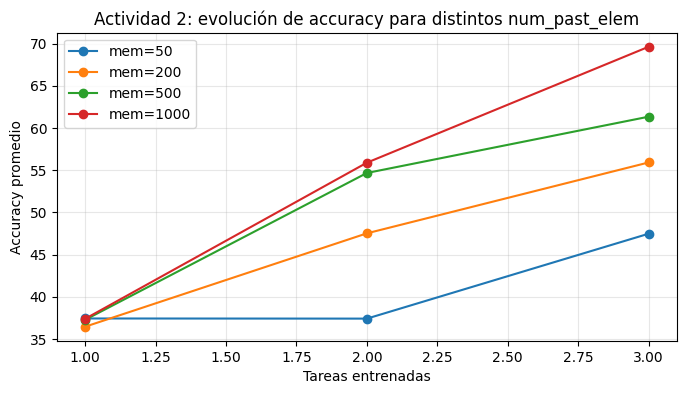


Memoria estimada en la última tarea (buffer de tareas previas):
mem=50: ~0.299 MB
mem=200: ~1.197 MB
mem=500: ~2.992 MB
mem=1000: ~5.983 MB
mem=50 -> final avg acc=47.4833
mem=200 -> final avg acc=55.9200
mem=500 -> final avg acc=61.3400
mem=1000 -> final avg acc=69.6233


In [30]:
# Actividad Práctica 2 - Experimentos Rehearsal
import sys
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import torch.optim as optim

# ---------------------------------------------------------------------
# Función auxiliar: ejecuta Rehearsal con un tamaño de memoria dado
# ---------------------------------------------------------------------
def run_rehearsal(tasks_sequence, num_past_elem_local=500, num_epoch_local=3):
    model_local = Net().to(device)
    optimizer_local = optim.SGD(model_local.parameters(), lr=0.01, momentum=0.9)

    avg_acc_history = []

    for task_id, task in enumerate(tasks_sequence):
        (x_train, y_train), _ = task

        # Agregamos muestras de tareas previas
        for i in range(task_id):
            (past_x_train, past_y_train), _ = tasks_sequence[i]
            k = min(num_past_elem_local, len(past_y_train))
            idx = random.sample(list(range(len(past_y_train))), k)
            x_train = np.concatenate((x_train, past_x_train[idx]))
            y_train = np.concatenate((y_train, past_y_train[idx]))

        # Muy importante: mezclar para no entrenar por bloques de tarea
        x_train, y_train = shuffle_in_unison([x_train, y_train], seed=0)

        for epoch in range(1, num_epoch_local):
            train(model_local, device, x_train, y_train, optimizer_local, epoch)

        avg_acc = 0.0
        for _, task_test in enumerate(tasks_sequence):
            _, (x_test, y_test) = task_test
            avg_acc += test(model_local, device, x_test, y_test)
        avg_acc /= len(tasks_sequence)
        avg_acc_history.append(avg_acc)

    return avg_acc_history

# ---------------------------
# 1) Curvas para varios num_past_elem
# ---------------------------
mem_sizes = [50, 200, 500, 1000]
rehe_results = {}

for m in mem_sizes:
    print(f'\n=== Rehearsal con num_past_elem={m} ===')
    rehe_results[m] = run_rehearsal(tasks, num_past_elem_local=m, num_epoch_local=num_epoch)
    print('Historial avg acc:', rehe_results[m])

plt.figure(figsize=(8, 4))
for m in mem_sizes:
    plt.plot(range(1, len(rehe_results[m]) + 1), rehe_results[m], '-o', label=f'mem={m}')
plt.xlabel('Tareas entrenadas')
plt.ylabel('Accuracy promedio')
plt.title('Actividad 2: evolución de accuracy para distintos num_past_elem')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ---------------------------
# 2) Estimación de memoria usada por rehearsal
# ---------------------------
x_sample_bytes = tasks[0][0][0][0].nbytes
y_sample_bytes = tasks[0][0][1][0].nbytes
bytes_per_sample = x_sample_bytes + y_sample_bytes

print('\nMemoria estimada en la última tarea (buffer de tareas previas):')
for m in mem_sizes:
    # En la tarea final, hay (num_tasks-1) tareas previas
    total_samples_buffer = m * (len(tasks) - 1)
    total_bytes = total_samples_buffer * bytes_per_sample
    total_mb = total_bytes / (1024 ** 2)
    print(f'mem={m}: ~{total_mb:.3f} MB')

# ---------------------------
# 3) Resumen numérico final
# ---------------------------
for m in mem_sizes:
    print(f'mem={m} -> final avg acc={rehe_results[m][-1]:.4f}')

## Elastic Weights Consolidation (EWC) Strategy

Como vimos en clases, EWC es una estrategia que se propuso en: "[Overcoming catastrophic forgetting in neural networks](https://arxiv.org/abs/1612.00796)".

Este método busca penalizar la modificación de ciertos pesos relevantes para tareas anteriores y que al modificarlos pueden provocar una reducción del rendimiento de estas tareas. Los pesos importantes se encuentran mediante la información de la matriz de Fisher, que se puede aproximar con el valor del gradiente al cuadrado.

Este método tiene la gran ventaja de que no necesita guardar elementos de tareas anteriores, lo cual lo hace eficiente con el uso de la memoria.

In [31]:
fisher_dict = {}
optpar_dict = {}
ewc_lambda = 0.7

In [32]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

Necesitamos una función que nos entregue la importancia de cada peso para cada una de las tareas, ya que como podemos ver en la siguiente ecuación:

> $L_{EWC} = \sum_i \frac{\lambda}{2} F_i (\theta_i - \theta_{A,i}^*) $

Cada peso tiene un valor asociado, si este valor es alto implica que es un peso importante y cambiarlo mucho aumentaría el valor de la función de pérdida.

Tal como hemos dicho, el valor de $F_i$ se puede aproximar con el gradiente:

> $ F_i =  g_i^2 $


In [33]:
def on_task_update(task_id, x_mem, t_mem, bs=256, fisher_clip=1e3):
  model.eval()  # desactiva dropout para medir Fisher
  # inicializa acumuladores en GPU
  fisher = {name: torch.zeros_like(p, device="cuda")
            for name, p in model.named_parameters() if p.requires_grad}
  N = 0  # nº de muestras acumuladas

  for start in range(0, len(t_mem), bs):
      end = min(start + bs, len(t_mem))
      x = torch.from_numpy(x_mem[start:end]).float().to(device)
      y = torch.from_numpy(t_mem[start:end]).long().to(device)

      model.zero_grad(set_to_none=True)
      out = model(x)
      loss = F.cross_entropy(out, y, reduction="mean")
      loss.backward()

      bsz = x.size(0)
      for name, p in model.named_parameters():
          if p.grad is None or not p.requires_grad:
              continue
          g = p.grad.detach()
          # acumula g^2 ponderado por tamaño de batch
          fisher[name] += (g * g).to("cuda") * bsz
      N += bsz

  # promedio sobre el nº total de muestras
  eps = 1e-12
  for name in fisher:
      f = fisher[name] / max(1, N)           # El valor esperado de [g^2]
      fisher[name] = f

  # guarda parámetros óptimos y Fisher en CPU
  fisher_dict[task_id] = {name: fisher[name] for name in fisher}
  optpar_dict[task_id] = {name: p.detach().clone()
                          for name, p in model.named_parameters() if p.requires_grad}

  model.train()

Como es una estrategia de regularización, necesitamos cambiar nuestra función de pérdida para agregar el el valor descrito anteriormente:

> $ L = L_T + L_{EWC} $


In [34]:
def train_ewc(model, device, task_id, x_train, t_train, optimizer, epoch):
    model.train()

    for start in range(0, len(t_train)-1, 256):
        end = start + 256
        x, y = torch.from_numpy(x_train[start:end]), torch.from_numpy(t_train[start:end]).long()
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)
        loss = F.cross_entropy(output, y)

        ### EWC! :-)
        for task in range(task_id):
            for name, param in model.named_parameters():
                fisher = fisher_dict[task][name]
                optpar = optpar_dict[task][name]
                loss += (fisher * (optpar - param).pow(2)).sum() * ewc_lambda

        loss.backward()
        optimizer.step()
        #print(loss.item())
    print('Train Epoch: {} \tLoss: {:.6f}'.format(epoch, loss.item()))

Con el método y las funciones ya definidas, solo nos queda entrenar nuestro modelo.

In [35]:
ewc_accs = []
for id, task in enumerate(tasks):
    avg_acc = 0
    print("Training on task: ", id)

    (x_train, y_train), _ = task

    for epoch in range(1, 3):
        train_ewc(model, device, id, x_train, y_train, optimizer, epoch)
    on_task_update(id, x_train, y_train)

    for id_test, task in enumerate(tasks):
        print("Testing on task: ", id_test)
        _, (x_test, y_test) = task
        acc = test(model, device, x_test, y_test)
        avg_acc = avg_acc + acc

    print("Avg acc: ", avg_acc / len(tasks))
    ewc_accs.append(avg_acc / len(tasks))

Training on task:  0
Train Epoch: 1 	Loss: 0.611922
Train Epoch: 2 	Loss: 0.447873
Testing on task:  0
Test set: Average loss: 0.0008, Accuracy: 9392/10000 (94%)

Testing on task:  1
Test set: Average loss: 0.0119, Accuracy: 543/10000 (5%)

Testing on task:  2
Test set: Average loss: 0.0104, Accuracy: 1155/10000 (12%)

Avg acc:  36.96666666666666
Training on task:  1
Train Epoch: 1 	Loss: 1.738315
Train Epoch: 2 	Loss: 1.377163
Testing on task:  0
Test set: Average loss: 0.0264, Accuracy: 1489/10000 (15%)

Testing on task:  1
Test set: Average loss: 0.0029, Accuracy: 7885/10000 (79%)

Testing on task:  2
Test set: Average loss: 0.0118, Accuracy: 1160/10000 (12%)

Avg acc:  35.11333333333333
Training on task:  2
Train Epoch: 1 	Loss: 1.752363
Train Epoch: 2 	Loss: 1.382537
Testing on task:  0
Test set: Average loss: 0.0190, Accuracy: 2332/10000 (23%)

Testing on task:  1
Test set: Average loss: 0.0103, Accuracy: 2349/10000 (23%)

Testing on task:  2
Test set: Average loss: 0.0024, Accur

### Actividad Práctica 3

* Graficar el accuracy promedio con diferentes valores de lambda. Explique los resultados.
* Compare la memoria extra utilizada por la estrategia de Rehersal (con 500 elementos por tarea) con lo utilizado por EWC. Explique el procedimiento y resultados, comparandolo con el mejor lambda obtenido en el punto anterior.


=== Entrenando EWC con lambda=0.0 ===
Train Epoch: 1 	Loss: 0.753902
Train Epoch: 2 	Loss: 0.669717
Test set: Average loss: 0.0008, Accuracy: 9370/10000 (94%)

Test set: Average loss: 0.0117, Accuracy: 642/10000 (6%)

Test set: Average loss: 0.0102, Accuracy: 1231/10000 (12%)

Train Epoch: 1 	Loss: 1.625604
Train Epoch: 2 	Loss: 1.347383
Test set: Average loss: 0.0208, Accuracy: 1383/10000 (14%)

Test set: Average loss: 0.0027, Accuracy: 8041/10000 (80%)

Test set: Average loss: 0.0129, Accuracy: 1105/10000 (11%)

Train Epoch: 1 	Loss: 1.583826
Train Epoch: 2 	Loss: 1.450222
Test set: Average loss: 0.0162, Accuracy: 2252/10000 (23%)

Test set: Average loss: 0.0073, Accuracy: 3471/10000 (35%)

Test set: Average loss: 0.0028, Accuracy: 7996/10000 (80%)

Historial avg acc: [37.47666666666667, 35.096666666666664, 45.73]

=== Entrenando EWC con lambda=0.01 ===
Train Epoch: 1 	Loss: 0.980256
Train Epoch: 2 	Loss: 0.740665
Test set: Average loss: 0.0008, Accuracy: 9378/10000 (94%)

Test set:

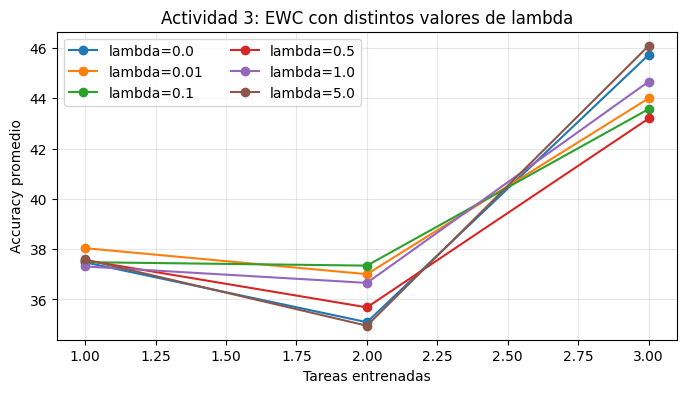


Mejor lambda (según avg acc final): 5.0
Accuracy promedio final con mejor lambda: 46.0900
Train Epoch: 1 	Loss: 0.805435
Train Epoch: 2 	Loss: 0.567773
Test set: Average loss: 0.0008, Accuracy: 9416/10000 (94%)

Test set: Average loss: 0.0117, Accuracy: 519/10000 (5%)

Test set: Average loss: 0.0099, Accuracy: 1255/10000 (13%)

Train Epoch: 1 	Loss: 1.611623
Train Epoch: 2 	Loss: 1.235503
Test set: Average loss: 0.0201, Accuracy: 1704/10000 (17%)

Test set: Average loss: 0.0024, Accuracy: 8228/10000 (82%)

Test set: Average loss: 0.0122, Accuracy: 1301/10000 (13%)

Train Epoch: 1 	Loss: 1.728168
Train Epoch: 2 	Loss: 1.250777
Test set: Average loss: 0.0205, Accuracy: 2427/10000 (24%)

Test set: Average loss: 0.0093, Accuracy: 2325/10000 (23%)

Test set: Average loss: 0.0029, Accuracy: 7980/10000 (80%)


--- Comparación de memoria extra ---
Rehearsal (500 por tarea previa): ~2.992 MB
EWC (Fisher + parámetros por tarea): ~0.500 MB
Razón Rehearsal/EWC: 5.985x


In [36]:
# Actividad Práctica 3 - Lambda sweep en EWC + comparación de memoria
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim

# ---------------------------------------------------------------------
# Función auxiliar: ejecuta EWC para un valor de lambda
# ---------------------------------------------------------------------
def run_ewc_lambda(tasks_sequence, lambda_value, num_epoch_local=3):
    global fisher_dict, optpar_dict, ewc_lambda, model, optimizer

    fisher_dict = {}
    optpar_dict = {}
    ewc_lambda = lambda_value
    model = Net().to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    avg_acc_history = []

    for task_id, task in enumerate(tasks_sequence):
        (x_train, y_train), _ = task

        for epoch in range(1, num_epoch_local):
            train_ewc(model, device, task_id, x_train, y_train, optimizer, epoch)

        on_task_update(task_id, x_train, y_train)

        avg_acc = 0.0
        for _, task_test in enumerate(tasks_sequence):
            _, (x_test, y_test) = task_test
            avg_acc += test(model, device, x_test, y_test)
        avg_acc /= len(tasks_sequence)
        avg_acc_history.append(avg_acc)

    return avg_acc_history, fisher_dict, optpar_dict

# ---------------------------
# 1) Sweep de lambdas
# ---------------------------
lambda_candidates = [0.0, 0.01, 0.1, 0.5, 1.0, 5.0]
ewc_sweep_results = {}

for lam in lambda_candidates:
    print(f'\n=== Entrenando EWC con lambda={lam} ===')
    acc_hist, _, _ = run_ewc_lambda(tasks, lam, num_epoch_local=num_epoch)
    ewc_sweep_results[lam] = acc_hist
    print('Historial avg acc:', acc_hist)

plt.figure(figsize=(8, 4))
for lam in lambda_candidates:
    plt.plot(range(1, len(ewc_sweep_results[lam]) + 1), ewc_sweep_results[lam], '-o', label=f'lambda={lam}')
plt.xlabel('Tareas entrenadas')
plt.ylabel('Accuracy promedio')
plt.title('Actividad 3: EWC con distintos valores de lambda')
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.show()

# Seleccionamos mejor lambda según accuracy final
best_lambda = max(lambda_candidates, key=lambda x: ewc_sweep_results[x][-1])
best_final_acc = ewc_sweep_results[best_lambda][-1]
print(f'\nMejor lambda (según avg acc final): {best_lambda}')
print(f'Accuracy promedio final con mejor lambda: {best_final_acc:.4f}')

# ---------------------------
# 2) Comparación de memoria: Rehearsal(500) vs EWC (mejor lambda)
# ---------------------------
# Memoria Rehearsal (aprox. buffer en última tarea)
x_sample_bytes = tasks[0][0][0][0].nbytes
y_sample_bytes = tasks[0][0][1][0].nbytes
bytes_per_sample = x_sample_bytes + y_sample_bytes
rehearsal_samples = 500 * (len(tasks) - 1)
rehearsal_mem_mb = (rehearsal_samples * bytes_per_sample) / (1024 ** 2)

# Memoria EWC (Fisher + parámetros por tarea)
_, best_fisher_dict, best_optpar_dict = run_ewc_lambda(tasks, best_lambda, num_epoch_local=num_epoch)

ewc_bytes = 0
for task_id in best_fisher_dict:
    for name in best_fisher_dict[task_id]:
        f = best_fisher_dict[task_id][name]
        p = best_optpar_dict[task_id][name]
        ewc_bytes += f.nelement() * f.element_size()
        ewc_bytes += p.nelement() * p.element_size()

ewc_mem_mb = ewc_bytes / (1024 ** 2)

print('\n--- Comparación de memoria extra ---')
print(f'Rehearsal (500 por tarea previa): ~{rehearsal_mem_mb:.3f} MB')
print(f'EWC (Fisher + parámetros por tarea): ~{ewc_mem_mb:.3f} MB')
if ewc_mem_mb > 0:
    print(f'Razón Rehearsal/EWC: {rehearsal_mem_mb / ewc_mem_mb:.3f}x')

## Comparación de Resultados

Para una mejor comparación de los métodos que vimos hoy en el laboratorio, vamos a graficar los resultados del accuracy promedio obtenido por los diferentes métodos, después de entrenar cada una de las tareas.

Con este gráfico estamos diciendo que no solo es importante no olvidar, sino que el poder aprender pesos que puedan servir a tareas futuras también es relevante.



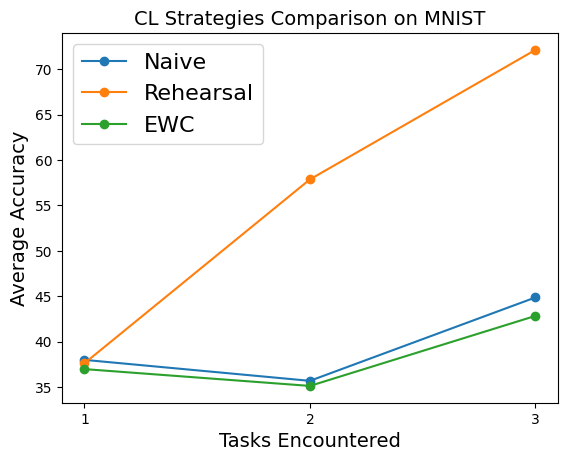

In [37]:
plt.plot([1, 2, 3], naive_accs, '-o', label="Naive")
plt.plot([1, 2, 3], rehe_accs, '-o', label="Rehearsal")
plt.plot([1, 2, 3], ewc_accs, '-o', label="EWC")
plt.xlabel('Tasks Encountered', fontsize=14)
plt.ylabel('Average Accuracy', fontsize=14)
plt.title('CL Strategies Comparison on MNIST', fontsize=14);
plt.xticks([1, 2, 3])
plt.legend(prop={'size': 16});

### Actividad Práctica 4

> Comparación conceptual de métodos (basado en el gráfico final)

> Naive
- Ventaja: simple de implementar y rápido de probar.
- Desventaja: fuerte olvido catastrófico cuando avanzan las tareas.
- Cuándo usarlo: como baseline inicial o prueba rápida.

> Rehearsal
- Ventaja: muy efectivo para retener tareas anteriores al reentrenar con muestras pasadas.
- Desventaja: necesita memoria extra (guardar datos) y puede tener restricciones de privacidad.
- Cuándo usarlo: cuando puedes almacenar datos y quieres buen desempeño práctico.

> EWC
- Ventaja: no necesita guardar muestras antiguas; protege pesos importantes con regularización.
- Desventaja: sensible al valor de `lambda`; si es muy bajo no protege, si es muy alto bloquea aprendizaje nuevo.
- Cuándo usarlo: cuando memoria o privacidad impiden guardar datos pasados.

> ¿Cuál es “mejor”?
No hay uno universalmente mejor. Depende del escenario:
- Si priorizas rendimiento y tienes memoria: Rehearsal suele ser fuerte.
- Si no puedes guardar datos: EWC es alternativa sólida.
- Naive rara vez gana en escenarios incrementales largos, pero sirve como referencia.

> Idea final
En aprendizaje incremental, la elección del método es un equilibrio entre:
- rendimiento promedio
- olvido en tareas antiguas
- costo de memoria
- costo computacional y restricciones de datos.

# Material Extra

*   Sequoia ([Github](https://github.com/lebrice/Sequoia))
*   Avalanche ([Pagina](https://avalanche.continualai.org/))
*   Curso Continual AI ([YouTube](https://www.youtube.com/watch?v=z9DDg2CJjeE&list=PLm6QXeaB-XkBfM5RgQP6wCR7Jegdg51Px&ab_channel=ContinualAI))

